# Naive Bayes Classification to Predict Titanic Survival

**Deep Dive Coding Data Science Bootcamp Sample Project**

---
Robert Citek - October 5th, 2026


## Problem Definition

State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.  Mention which model will be used, if known.

## Data Collection/Sources

### Data Overview

This data comes from [Kaggle](https://www.kaggle.com/c/titanic/data), which was then copied to AWS for easy access.

https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv


### Imports

In [1]:
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

Create a variable `url` that contains the web link to the CSV data

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'    # insert url here
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Example/Data/Titanic.train.csv'

### Load data

Load the data into a data frame named `titanic_df`.

In [3]:
# load data
titanic_df = pd.read_csv( url )
titanic_df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### head

Look at the first few rows

In [4]:
# first few rows
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail

Look at the last few rows


In [5]:
# last few rows
titanic_df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### shape


In [6]:
# shape of data frame
titanic_df.shape


(891, 12)

### size


In [7]:
# size of data frame
titanic_df.size


10692

### Summary meta-data

Run the `info()` method on the data frame.


In [8]:
# display meta-data
titanic_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

Summary statistics give you a quick overview of the data.  Some items to spot check:
- the Target:
  - look for nulls
    - null will be culled
  - look at min, max, median, and mean
    - is it a categorical field masquerading as a number?
- the Features:
  - numerical
    - look at min, max, median, and mean
      - a min=1 and max=count suggests an ID
  - categorical
    - look at unique and freq
      - freq=1, unique=count suggests an ID
      - freq=count suggests a meaningless feature

Run the `describe()` method on the data frame.

In [9]:
# display summary statistics
titanic_df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### target value_counts()


The target should be the first field that you look at.  Its data type will tell you what kind of machine learning problem this is ( classification or regression. ) Any nulls should be culled.  You can check for any skew in the data set.

In [10]:
# value_counts on target ; include nulls
titanic_df['Survived'].value_counts(dropna=False)


,count
Survived,
0,549
1,342


In [11]:
# normalized value_counts on target ; include nulls
titanic_df['Survived'].value_counts(dropna=False, normalize=True) * 100


,proportion
Survived,
0,61.616162
1,38.383838


### Nulls



In [12]:
# look for nulls
titanic_df.isnull().sum().sort_values(ascending=False)


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [13]:
titanic_df.isnull().mean().sort_values() * 100


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.224467


In [14]:
# look for nulls, displaying relative frequency
null_sum = titanic_df.isnull().sum()
null_frequency = null_sum / titanic_df.shape[0] * 100
null_frequency.sort_values()


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.224467


### dtypes - column data types

Which data types would be appropriate for Gaussian Naive Bayes?


In [15]:
# display data types
titanic_df.dtypes.sort_values()


,0
PassengerId,int64
Survived,int64
Pclass,int64
SibSp,int64
Parch,int64
Age,float64
Fare,float64
Name,object
Sex,object
Ticket,object


In [16]:
titanic_df.dtypes.value_counts()


,count
int64,5
object,5
float64,2


### Unique elements


If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.


In [27]:
# number of unique elements in a column
titanic_df.nunique().sort_values(ascending=False)


,0
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,147
Age,88
SibSp,7
Parch,7
Embarked,3
Pclass,3


## Data Cleaning


### Backup #1


In [28]:
# make backup
titanic_df_bak = titanic_df.copy()
titanic_df_bak


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [33]:
# restore from backup
titanic_df = titanic_df_bak.copy()
titanic_df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Keep only the target and one feature

Select `Survived` for the target and `Fare` for the single feature

In [34]:
# select the target and one feature
titanic_df_target_features = titanic_df[["Survived", "Fare"]]
titanic_df_target_features


,Survived,Fare
0,0,7.2500
1,1,71.2833
2,1,7.9250
3,1,53.1000
4,0,8.0500
...,...,...
886,0,13.0000
887,1,30.0000
888,0,23.4500
889,1,30.0000


### Backup #2


In [35]:
# make backup
titanic_df_target_features_bak = titanic_df_target_features.copy()
titanic_df_target_features_bak


,Survived,Fare
0,0,7.2500
1,1,71.2833
2,1,7.9250
3,1,53.1000
4,0,8.0500
...,...,...
886,0,13.0000
887,1,30.0000
888,0,23.4500
889,1,30.0000


In [36]:
# restore from backup
titanic_df_target_features = titanic_df_target_features_bak.copy()
titanic_df_target_features


,Survived,Fare
0,0,7.2500
1,1,71.2833
2,1,7.9250
3,1,53.1000
4,0,8.0500
...,...,...
886,0,13.0000
887,1,30.0000
888,0,23.4500
889,1,30.0000


### Address any rows with nulls

- If the number of nulls in a column is low, it would be easiest to drop the row.
- If the number of nulls in a column is high, it would be easiest to drop the column.
- If the number of nulls in a column is between the low and high, one should impute values for the nulls.


In [37]:
titanic_df_target_features.isnull().sum().sort_values(ascending=False)


,0
Survived,0
Fare,0


#### Impute

Impute with the median.

However, there are no nulls.  So, we'll keep the code cells as placeholders, but not need them.


In [ ]:
# Calculate the median


In [ ]:
# Assign median to nulls


In [ ]:
# Verify there are no nulls


In [ ]:
# Verify median is about the same as before


## Exploratory Data Analysis


GNB has two requirements:
1. the features are normally distributed
1. the features are not correlated with each other

### normal distribution of features: histogram


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

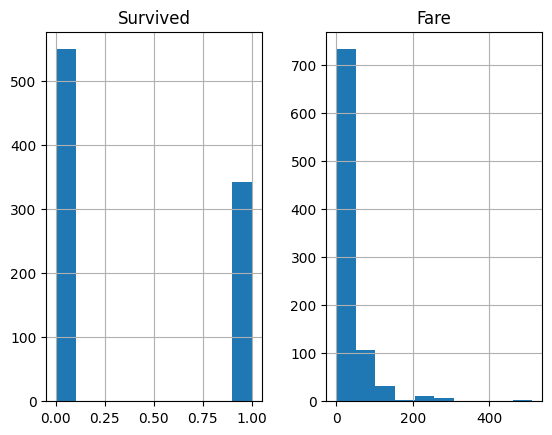

In [38]:
# Display a histogram
titanic_df_target_features.hist()


### No correlation with a single feature



## Processing



In [41]:
# Split data frame into target and features
target_col = 'Survived'
target = titanic_df_target_features[ target_col ]
features = titanic_df_target_features.drop( columns=[target_col])


In [42]:
# Verify features
features


,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [43]:
type(features)


pandas.core.frame.DataFrame

In [45]:
features.ndim


2

In [40]:
# Verify target
target


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [44]:
type(target)


pandas.core.series.Series

In [46]:
target.ndim


1

### Single Cross Validation ( CV )

Run a single Cross Validation

#### Train Test Split

In [47]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split( features, target, test_size=0.25 )


In [78]:
# Verify shape of each data set from Train Test Split
for i in [ x_train, x_test, y_train, y_test ]:
  print(i.shape)
  print(type(i))


(668, 1)
<class 'pandas.core.frame.DataFrame'>
(223, 1)
<class 'pandas.core.frame.DataFrame'>
(668,)
<class 'pandas.core.series.Series'>
(223,)
<class 'pandas.core.series.Series'>


#### Model


In [50]:
# Create an empty GNB model
modelGNB = GaussianNB()


#### Fit



In [52]:
# Train ( fit ) the model
modelGNB.fit( (x_train), y_train )


GaussianNB()

#### Prediction


In [53]:
# Make predicitons using the model
y_pred = modelGNB.predict(x_test)


#### Performance


We'll meassure accuracy, which is the proportions of the number correctly predicted, which is mathematically the same as one minus the proportion incorrectly predicted.

In [54]:
# Calculate the accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
accuracy * 100


66.3677130044843

<Axes: >

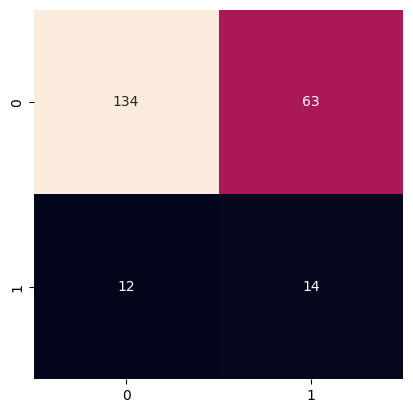

In [57]:
# Display a confusion matrix
mat = metrics.confusion_matrix( y_test, y_pred, )
sns.heatmap( mat.T,
    square=True,
    annot=True,
    fmt = "d",
    cbar = False,
)

### Multiple Cross Validation ( CV )

Create a CV loop with 100 iterations.  Capture performance metric in an array names `results`.
Use accuracy for the performance metric.


In [72]:
# Create array to hold results
n = 5000
results = np.zeros(n)
# results


In [73]:
# Multiple CV loop
for i in range(n):
  # Train Test Split
  x_train, x_test, y_train, y_test = train_test_split( features, target, test_size=0.25 )

  # Create an empty GNB model
  modelGNB = GaussianNB()

  # Train ( fit ) the model
  modelGNB.fit( (x_train), y_train )

  # Make predicitons using the model
  y_pred = modelGNB.predict(x_test)

  # Calculate the accuracy
  results[i] = metrics.accuracy_score(y_test, y_pred)


In [74]:
# Calculate mean of results
results.mean()


np.float64(0.6690304932735426)

<Axes: >

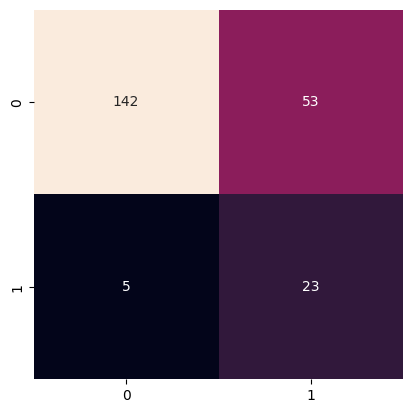

In [75]:
# Display a confusion matrix
mat = metrics.confusion_matrix( y_test, y_pred, )
sns.heatmap( mat.T,
    square=True,
    annot=True,
    fmt = "d",
    cbar = False,
)

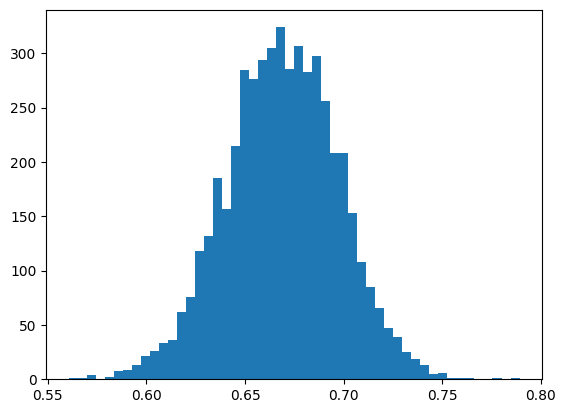

In [77]:
# Display a histogram of the results
plt.hist(results, bins=50) ;


## Communication of Results

Conclusion:
- Fare gaves us 66.8% accuracy, which is a little better than Age.
- Very good at predicting non-survival.  Not so good at predicting servival.  Fairly high false negatives.  This may be because the data set is not balanced.
-





Future work:
- combine Age and Fare
- balance data set
- try other ML method

